/tmp/ipykernel_323535/1327845877.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha="right", fontsize=11)


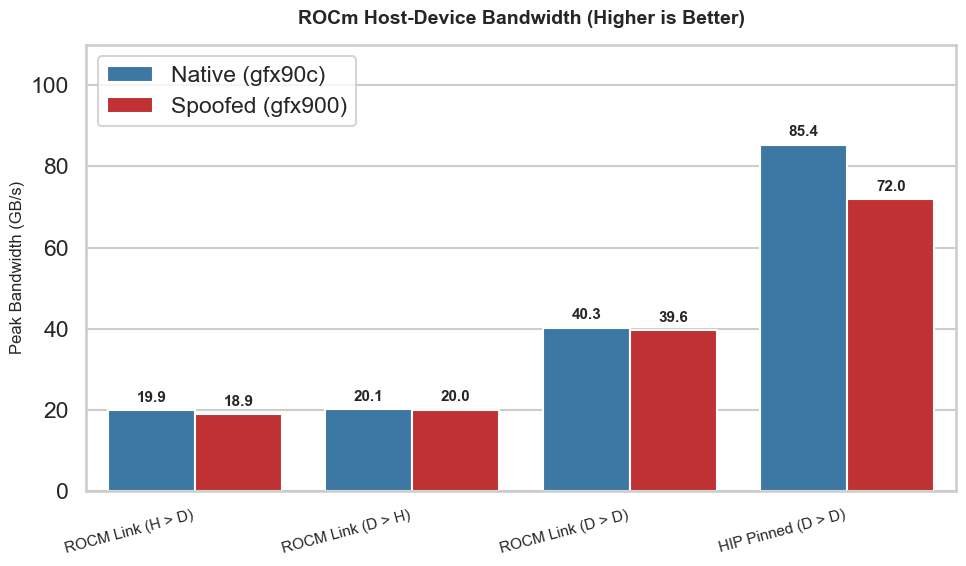

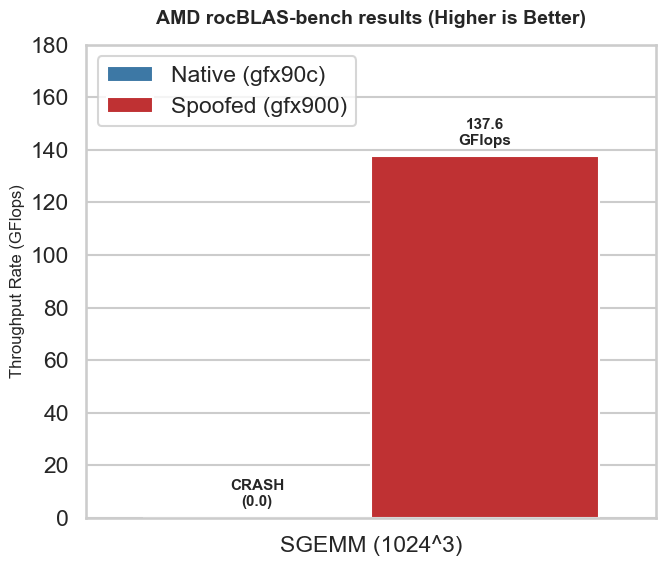

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize a clean, modern theme
sns.set_theme(style="whitegrid", context="talk")

# -------------------------------------------------------------------------
# Long-Form Data Construction
# -------------------------------------------------------------------------
data_records = [
    # System Link Infrastructure Metrics (Bandwidth)
    {"Subsystem": "Bus Infrastructure", "Context": "ROCM Link (H > D)", "Architecture": "Native (gfx90c)", "Performance": 19.907},
    {"Subsystem": "Bus Infrastructure", "Context": "ROCM Link (H > D)", "Architecture": "Spoofed (gfx900)", "Performance": 18.867},
    {"Subsystem": "Bus Infrastructure", "Context": "ROCM Link (D > H)", "Architecture": "Native (gfx90c)", "Performance": 20.059},
    {"Subsystem": "Bus Infrastructure", "Context": "ROCM Link (D > H)", "Architecture": "Spoofed (gfx900)", "Performance": 19.992},
    {"Subsystem": "Bus Infrastructure", "Context": "ROCM Link (D > D)", "Architecture": "Native (gfx90c)", "Performance": 40.251},
    {"Subsystem": "Bus Infrastructure", "Context": "ROCM Link (D > D)", "Architecture": "Spoofed (gfx900)", "Performance": 39.607},
    {"Subsystem": "Bus Infrastructure", "Context": "HIP Pinned (D > D)", "Architecture": "Native (gfx90c)", "Performance": 85.379},
    {"Subsystem": "Bus Infrastructure", "Context": "HIP Pinned (D > D)", "Architecture": "Spoofed (gfx900)", "Performance": 71.954},
    
    # Core Compute Kernel Execution Metrics (Throughput)
    {"Subsystem": "Compute Kernels", "Context": "SGEMM (1024^3)", "Architecture": "Native (gfx90c)", "Performance": 0.000},
    {"Subsystem": "Compute Kernels", "Context": "SGEMM (1024^3)", "Architecture": "Spoofed (gfx900)", "Performance": 137.622}
]

df = pd.DataFrame(data_records)
palette_pair = {"Native (gfx90c)": "#2c7bb6", "Spoofed (gfx900)": "#d7191c"}

# -------------------------------------------------------------------------
# Plot 1: Bus Infrastructure (Bandwidth Benchmark)
# -------------------------------------------------------------------------
df_bus = df[df["Subsystem"] == "Bus Infrastructure"]
fig1, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_bus, 
    x="Context", 
    y="Performance", 
    hue="Architecture", 
    palette=palette_pair, 
    ax=ax1
)

# Self-contained title and axis configurations
ax1.set_title("ROCm Host-Device Bandwidth (Higher is Better)", fontsize=14, pad=15, weight='bold')
ax1.set_ylabel("Peak Bandwidth (GB/s)", fontsize=12)
ax1.set_xlabel("")
ax1.set_ylim(0, 110)  # Padded to comfortably clear text labels & legends
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha="right", fontsize=11)
ax1.legend(loc="upper left", frameon=True)

# Format and inject bar value labels safely
for container in ax1.containers:
    labels = [f"{v.get_height():.1f}" for v in container]
    ax1.bar_label(container, labels=labels, padding=4, fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig("bus_infrastructure.png", dpi=150)
plt.show()

# -------------------------------------------------------------------------
# Plot 2: Compute Kernels (Throughput Benchmark)
# -------------------------------------------------------------------------
df_comp = df[df["Subsystem"] == "Compute Kernels"]
fig2, ax2 = plt.subplots(figsize=(7, 6))

sns.barplot(
    data=df_comp, 
    x="Context", 
    y="Performance", 
    hue="Architecture", 
    palette=palette_pair, 
    ax=ax2
)

# Self-contained title and axis configurations
ax2.set_title("AMD rocBLAS-bench results (Higher is Better)", fontsize=14, pad=15, weight='bold')
ax2.set_ylabel("Throughput Rate (GFlops)", fontsize=12)
ax2.set_xlabel("")
ax2.set_ylim(0, 180)  # Extended limit prevents text labels from clashing with the legend
ax2.legend(loc="upper left", frameon=True)

# Format and handle both normal outputs and crashes cleanly
for container in ax2.containers:
    labels = []
    for bar in container:
        val = bar.get_height()
        if val == 0.0:
            labels.append("CRASH\n(0.0)")
        else:
            labels.append(f"{val:.1f}\nGFlops")
    ax2.bar_label(container, labels=labels, padding=6, fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig("compute_kernels.png", dpi=150)
plt.show()